In [2]:
from evaluate import *

## Test Dataset Size

In [3]:
results = open_json_file("../model_training/outputs/zero_shot_results.json")
print(f"Number of test samples: {len(results)}")

Number of test samples: 899


## Valid answers ratio

In [12]:
void_output = get_void_output("../model_training/outputs/zero_shot_results.json")
print(f"Number of valide outputs: {len(results) - void_output[0]}")
print(f"Valid answers ratio over all inputs: {1 - void_output[1]}")

Number of valide outputs: 766
Valid answers ratio over all inputs: 0.8520578420467186


## EMA : Exact Match Accuracy

In [13]:
EMA = get_EMA("../model_training/outputs/zero_shot_results.json")
print(f"Exact Match: {EMA}")
print(f"Exact Match Ratio over all outputs: {EMA / len(results)}")
print(f"Exact Match Ratio over valid outputs: {EMA / (len(results) - void_output[0])}")

Exact Match: 93
Exact Match Ratio over all outputs: 0.10344827586206896
Exact Match Ratio over valid outputs: 0.12140992167101827


## EA : Execution Accuracy

In [14]:
EA = get_execution_accuracy("../model_training/outputs/zero_shot_results.json", "../data_processing/spider/database")
print(f"Execution Accuracy: {EA}")
print(f"Execution Accuracy Ratio over all inputs: {EA / len(results)}")
print(f"Execution Accuracy Ratio over valid inputs: {EA / (len(results) - void_output[0])}")

Execution Accuracy: 349
Execution Accuracy Ratio over all inputs: 0.3882091212458287
Execution Accuracy Ratio over valid inputs: 0.4556135770234987


## Sintax Validity

In [15]:
syntax_validity = get_syntax_validity("../model_training/outputs/zero_shot_results.json", "../data_processing/spider/database")
print(f"Sinatx Validity: {syntax_validity[0]}")
print(f"Sinatx Validity Ratio over all inputs: {syntax_validity[1]}")
print(f"Sinatx Validity Ratio over valid inputs: {syntax_validity[0]/(len(results) - void_output[0])}")

Sinatx Validity: 611
Sinatx Validity Ratio over all inputs: 0.6796440489432704
Sinatx Validity Ratio over valid inputs: 0.7976501305483029


## F1 Recall Precision

In [12]:
f1, recall, precision = get_f1_score("../model_training/outputs/zero_shot_results.json")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")

F1 Score: 0.4210526315789474
Recall: 0.3333333333333333
Precision: 0.5714285714285714


## BLEU Score

In [11]:
bleu = get_BLEU_score("../model_training/outputs/zero_shot_results.json")
print(f"BLEU Score: {bleu}")

BLEU Score: 0.06737889001875311


In [1]:
from evaluate import test_sql_commands_and_categorize_errors
output_path = "../model_training/outputs/zero_shot_results.json"
db_path = "../data_processing/spider/database"
sql_errors, error_counts = test_sql_commands_and_categorize_errors(output_path, db_path)

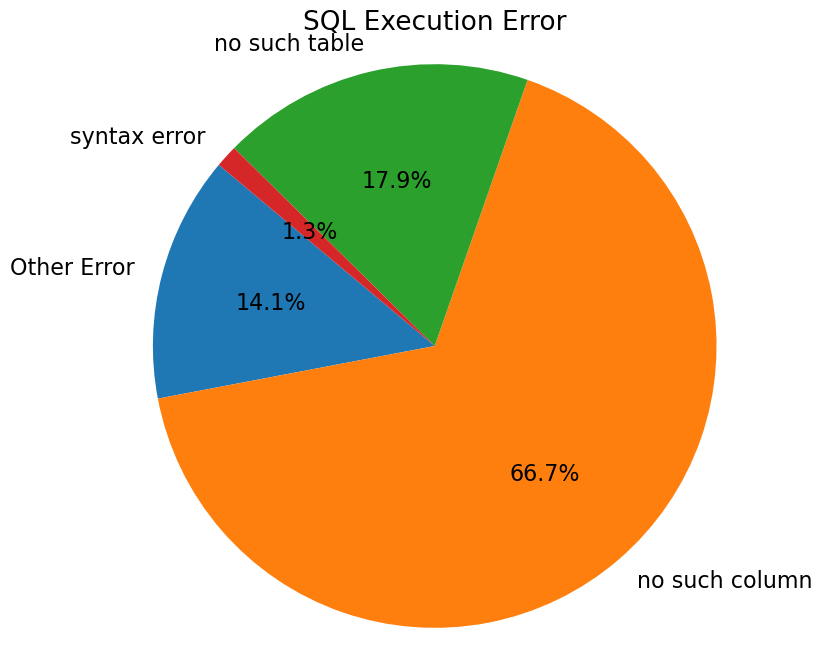

In [7]:
import matplotlib.pyplot as plt
# Extract the error types and their counts
error_types = list(error_counts.keys())
counts = list(error_counts.values())

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=error_types, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 16})
plt.title('SQL Execution Error', fontsize=19)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the pie chart
plt.show()

In [1]:
from evaluate import find_keywords_in_failed_queries
output_path = "../model_training/outputs/zero_shot_results.json"
db_path = "../data_processing/spider/database"
failed_queries = find_keywords_in_failed_queries(output_path, db_path)

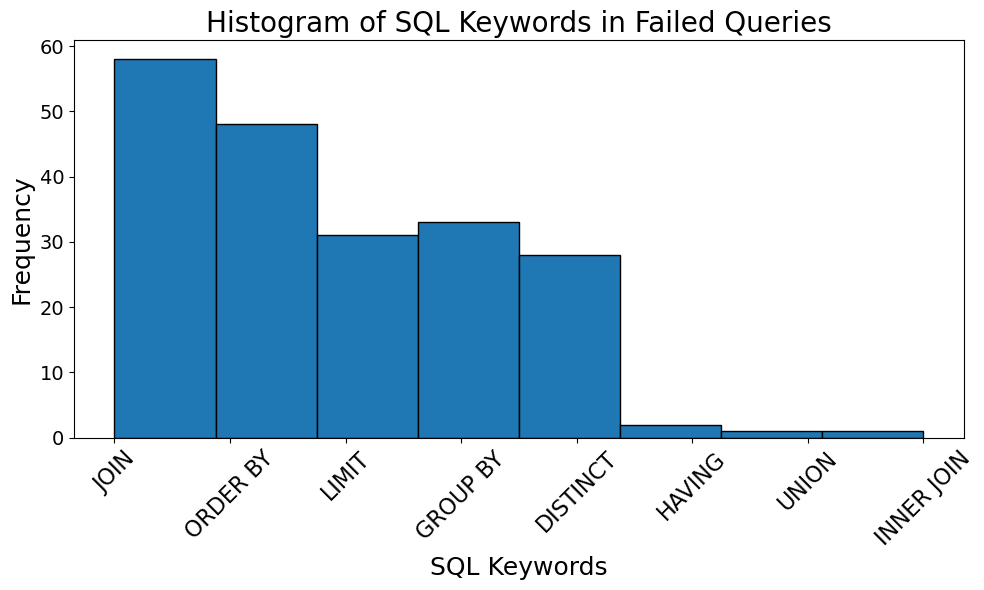

In [8]:
import matplotlib.pyplot as plt
keywords = [keyword for query in failed_queries for keyword in query["keywords"]]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(keywords, bins=len(set(keywords)), edgecolor='black')
plt.title('Histogram of SQL Keywords in Failed Queries', fontsize=20)
plt.xlabel('SQL Keywords', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=14)
plt.tight_layout()

# Display the histogram
plt.show()